In [1]:
import matplotlib as mpl

# Increase global text/tick/legend sizing for all plots
mpl.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

  IC3392: 49984 valid spaxels (flux+SFR+EW mask)
  NGC4064: 111655 valid spaxels (flux+SFR+EW mask)
  NGC4192: 458926 valid spaxels (flux+SFR+EW mask)
  NGC4293: 141156 valid spaxels (flux+SFR+EW mask)
  NGC4298: 277437 valid spaxels (flux+SFR+EW mask)
  NGC4330: 88572 valid spaxels (flux+SFR+EW mask)
  NGC4383: 127766 valid spaxels (flux+SFR+EW mask)
  NGC4396: 155963 valid spaxels (flux+SFR+EW mask)
  NGC4419: 126953 valid spaxels (flux+SFR+EW mask)
  NGC4457: 227739 valid spaxels (flux+SFR+EW mask)
  NGC4501: 578518 valid spaxels (flux+SFR+EW mask)
  NGC4522: 82367 valid spaxels (flux+SFR+EW mask)
  NGC4694: 59616 valid spaxels (flux+SFR+EW mask)
  NGC4698: 218649 valid spaxels (flux+SFR+EW mask)

Total combined valid spaxels (flux+SFR+EW mask): 2705301

SFR component counts (finite spaxels, all galaxies combined):
  HII: 858007 (31.438%)
  NONHII: 1696476 (62.160%)
  UNCLASSIFIED2: 174710 (6.402%)

SF component counts (finite spaxels, all galaxies combined):
  SF: 1252439 (45.890%)

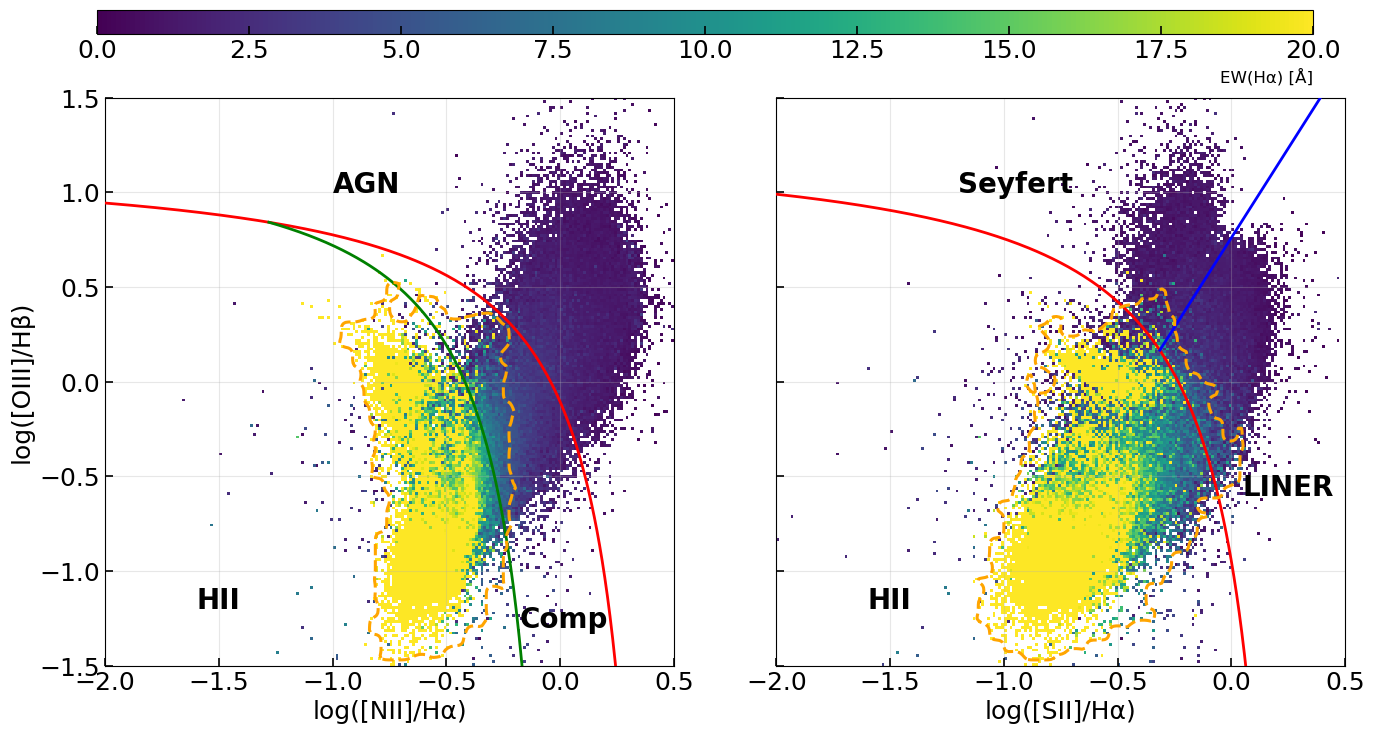


Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Orange dashed contour marks boundary of EW(Hα) > 6 Å


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color by EW(Halpha)
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import binary_closing, binary_fill_holes, gaussian_filter, label


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Error propagation for BPT ratios (log10 numerator/denominator)
def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
        return log_ratio_err


def plot_closed_ew_boundary(ax, ew_grid, xedges, yedges, ew_threshold):
    finite_mask = np.isfinite(ew_grid)
    if not np.any(finite_mask):
        return

    gt_mask = finite_mask & (ew_grid > ew_threshold)
    if np.count_nonzero(gt_mask) < 10:
        return

    # Clean up isolated cells and fill small holes to form a closed boundary.
    cleaned = binary_closing(gt_mask, structure=np.ones((3, 3), dtype=bool), iterations=2)
    cleaned = binary_fill_holes(cleaned)

    labeled, n_regions = label(cleaned)
    if n_regions == 0:
        return

    region_sizes = np.bincount(labeled.ravel())
    region_sizes[0] = 0
    largest_region = labeled == np.argmax(region_sizes)

    smooth_region = gaussian_filter(largest_region.astype(float), sigma=1.2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        smooth_region.T,
        levels=[0.5],
        colors='orange',
        linestyles='--',
        linewidths=2.2,
        zorder=11,
    )


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_CONTOUR = 6.0


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_ew = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if gas_file.exists() and bin_file.exists() and ew_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
            HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
            OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
            NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
            SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
            SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
            logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
            logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
            logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data

        with fits.open(ew_file) as h_ew:
            if EW_HDU not in h_ew:
                print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                continue
            ew_ha = h_ew[EW_HDU].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            print(f'  {gal}: shape mismatch EW {ew_ha.shape} vs gas {HA6562_FLUX_corr.shape}')
            continue

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
            np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
            np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
            np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
            np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
            np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # EW mask
        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask & ew_mask
        n_pixels = np.sum(valid_mask)
        print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())
        all_ew.extend(EW_common.flatten())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
            np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
            np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
            np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
            np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
            np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not bin_file.exists():
            missing_parts.append(bin_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_ew = np.array(all_ew)

if len(all_logN2) == 0:
    raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
if len(all_ew) != len(all_logN2):
    raise RuntimeError('EW array length mismatch with BPT arrays.')

# Report SFR component stats
print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
if count_union > 0:
    print('\nSFR component counts (finite spaxels, all galaxies combined):')
    print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
    print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

if count_union > 0:
    print('\nSF component counts (finite spaxels, all galaxies combined):')
    print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
    print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
    print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
    print(f'  Max |Δ|: {max_abs_diff:.3e}')

# Mean log-errors for requested subsets

def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan

print('\nMean log-error (spaxel subsets):')
print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

# Create diagrams for all spaxels (2D EW color)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

# Binning and ranges
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3
vmin_ew = 0.0
vmax_ew = 20.0

# NII panel EW grid
hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_N2, _, _ = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_N2 = np.divide(
    sum_ew_N2,
    hist_N2,
    out=np.full_like(sum_ew_N2, np.nan, dtype=float),
    where=hist_N2 > 0,
)
mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

# SII panel EW grid
hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_S2, _, _ = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_S2 = np.divide(
    sum_ew_S2,
    hist_S2,
    out=np.full_like(sum_ew_S2, np.nan, dtype=float),
    where=hist_S2 > 0,
)
mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

# NII diagram
ax = axes[0]
img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_invalid(mean_ew_N2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_N2, xedges_N2, yedges_N2, EW_CONTOUR)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_invalid(mean_ew_S2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_S2, xedges_S2, yedges_S2, EW_CONTOUR)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# Shared colorbar (top, spanning both panels)
cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal')
cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
cbar.ax.tick_params(labelsize=18)

# Save figures
output_dir = Path('Plot_Paper_1_referee')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
plt.show()

print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
print('Galaxies included: ' + ', '.join(galaxies))
print(f'Orange dashed contour marks boundary of EW(Hα) > {EW_CONTOUR:g} Å')

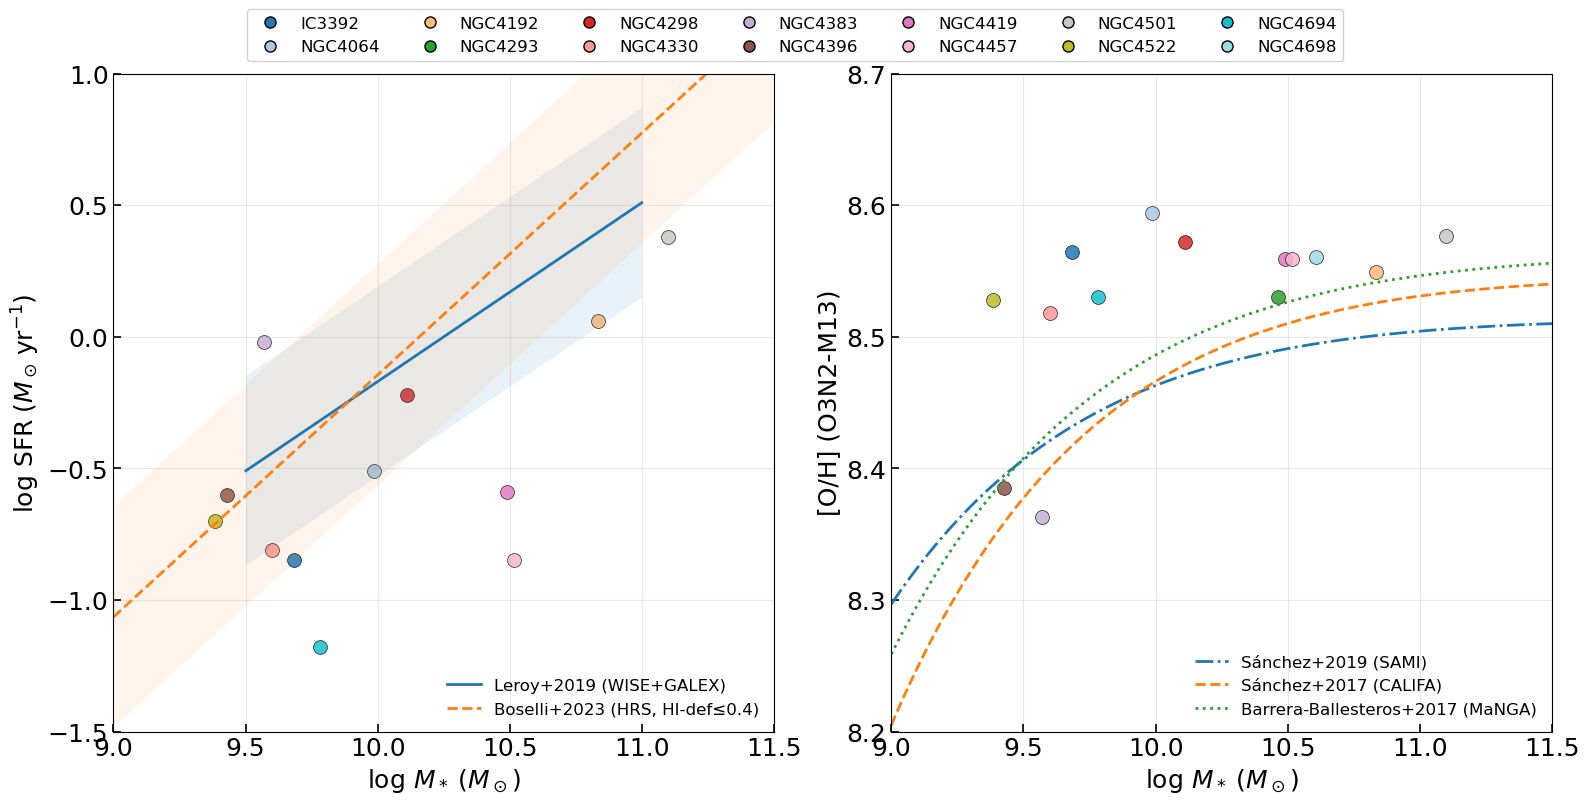

Subplot 1 (Integrated SFMS): Plotted 14 galaxies with valid total mass and SFR data
Subplot 2 (Integrated MZR, O3N2-M13 HII): Plotted 14 galaxies with valid total mass and HII metallicity data


In [3]:
# ------------------------------------------------------------------
# Combined Plot: Integrated SFMS + Integrated MZR (O3N2-M13 HII)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re


def extract_total_stellar_mass(galaxy_name):
    """Extract total stellar mass from mass log file. Returns log10(M☉) or None."""
    log_file = Path(f'mass_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total stellar mass \(R\)\s*:\s*([\d.-]+)\s*log10\(M☉\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading mass log for {galaxy_name}: {e}")
        return None


def extract_total_sfr(galaxy_name):
    """Extract total SFR from SFR log file. Returns log10(M☉/yr) or None."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total Halpha SFR from SF region:.*?in log10 scale:\s*([\d.-]+)\s*log\(M☉/yr\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading SFR log for {galaxy_name}: {e}")
        return None


def extract_total_o3n2_m13_hii_metallicity(galaxy_name):
    """Extract total O3N2-M13 HII metallicity from SFR log file. Returns [O/H] or None."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'\[O/H\] O3N2-M13 HII: Total metallicity in HII region:\s*([\d.-]+)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading O3N2-M13 HII metallicity log for {galaxy_name}: {e}")
        return None


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def ≤ 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_sanchez2019(logM, a=8.51, b=0.007, c=3.5):
    """Sánchez+2019 SAMI relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_sanchez2017(logM, a=8.54, b=0.011, c=3.5):
    """Sánchez+2017 CALIFA relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_barrera_ballesteros2017_m13(logM, a=8.56, b=0.005, c=4.0):
    """Barrera-Ballesteros+2017 MaNGA characteristic-abundance relation (O3N2-M13)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


# def mzr_alvarez_hurtado2022_m13_exp(logM, a, b, c=3.5):
#     """
#     Alvarez-Hurtado+2022 eCALIFA exponential-form MZR:
#         y = a + b * (x8 - c) * exp(-(x8 - c))
#     where x8 = logM - 8
#     """
#     logM = np.asarray(logM, dtype=float)
#     x8 = logM - 8.0
#     t = x8 - c
#     return a + b * t * np.exp(-t)


# Coefficients used for plotting the AH22 exponential-form relation
AH22_M13_A = 8.72
AH22_M13_B = 0.005

# Discover galaxies from binning files
galaxy_files = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in galaxy_files]

# Integrated SFMS containers
sfms_masses = []
sfms_sfrs = []
sfms_names = []

# Integrated MZR containers (HII metallicity)
mzr_masses = []
mzr_oh_hii = []
mzr_names = []

for gal in galaxies:
    mass = extract_total_stellar_mass(gal)
    sfr = extract_total_sfr(gal)
    oh_hii = extract_total_o3n2_m13_hii_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_hii is not None:
        mzr_masses.append(mass)
        mzr_oh_hii.append(oh_hii)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_hii = np.array(mzr_oh_hii)

# Consistent colors across both panels
if len(galaxies) > 0:
    galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
    galaxy_color_dict = dict(zip(galaxies, galaxy_colors))
else:
    galaxy_color_dict = {}

# Build figure with only two integrated subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ------------------------------------------------------------------
# SUBPLOT 1: Integrated SFMS
# ------------------------------------------------------------------
for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, 'tab:blue')
    ax1.scatter(mass, sfr, s=100, c=[color], alpha=0.85, edgecolors='black', linewidth=0.5)

x_sfms = np.linspace(9.0, 11.5, 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax1.plot(x_sfms, y_l19, lw=2, ls='-', label='Leroy+2019 (WISE+GALEX)')
ax1.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, alpha=0.10, linewidth=0)
ax1.plot(x_sfms, y_b23, lw=2, ls='--', label='Boselli+2023 (HRS, HI-def≤0.4)')
ax1.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)

ax1.set_xlabel(r'$\log\,M_* \; (M_\odot)$')
ax1.set_ylabel(r'$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$')
# ax1.set_title('Integrated Star-Forming Main Sequence')
ax1.set_xlim(9.0, 11.5)
ax1.set_ylim(-1.5, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False, loc='lower right')

# ------------------------------------------------------------------
# SUBPLOT 2: Integrated MZR (O3N2-M13 HII)
# ------------------------------------------------------------------
for mass, oh_hii, gal in zip(mzr_masses, mzr_oh_hii, mzr_names):
    color = galaxy_color_dict.get(gal, 'tab:orange')
    ax2.scatter(mass, oh_hii, s=100, c=[color], alpha=0.85, edgecolors='black', linewidth=0.5)

x_mzr = np.linspace(9.0, 11.5, 400)
ax2.plot(x_mzr, mzr_sanchez2019(x_mzr), lw=2, ls='-.', label='Sánchez+2019 (SAMI)')
ax2.plot(x_mzr, mzr_sanchez2017(x_mzr), lw=2, ls='--', label='Sánchez+2017 (CALIFA)')
ax2.plot(x_mzr, mzr_barrera_ballesteros2017_m13(x_mzr), lw=2, ls=':', label='Barrera-Ballesteros+2017 (MaNGA)')
# ax2.plot(
#     x_mzr,
#     mzr_alvarez_hurtado2022_m13_exp(x_mzr, AH22_M13_A, AH22_M13_B),
#     lw=2,
#     ls='-',
#     color='black',
#     alpha=0.9,
#     label='Alvarez-Hurtado+2022 (eCALIFA)',
# )

ax2.set_xlabel(r'$\log\,M_* \; (M_\odot)$')
ax2.set_ylabel(r'[O/H] (O3N2-M13)')
# ax2.set_title('Integrated Mass-Metallicity Relation (O3N2-M13 HII)')
ax2.set_xlim(9.0, 11.5)
ax2.set_ylim(8.2, 8.7)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False, loc='lower right')

# Shared galaxy legend for both subplots (replaces per-point text annotations)
plotted_galaxies = [gal for gal in galaxies if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0], [0], marker='o', color='none', linestyle='None', markersize=8,
        markerfacecolor=galaxy_color_dict.get(gal, 'gray'), markeredgecolor='black'
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=min(len(plotted_galaxies), 7),
        framealpha=0.9,
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = Path('Plot_Paper_1_referee')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'Integrated_SFMS_MZR_HII.png', dpi=600, bbox_inches='tight')
fig.savefig(output_dir / 'Integrated_SFMS_MZR_HII.pdf', bbox_inches='tight')
plt.show()

print(f"Subplot 1 (Integrated SFMS): Plotted {len(sfms_names)} galaxies with valid total mass and SFR data")
print(f"Subplot 2 (Integrated MZR, O3N2-M13 HII): Plotted {len(mzr_names)} galaxies with valid total mass and HII metallicity data")